In [2]:
!pip install -U tokenizers transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [3]:
!git clone https://github.com/apache/tika.git && cd tika && git checkout b6bcce634

Cloning into 'tika'...
remote: Enumerating objects: 241880, done.
remote: Counting objects: 100% (363/363), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 241880 (delta 194), reused 223 (delta 145), pack-reused 241517 (from 2)
Receiving objects: 100% (241880/241880), 347.77 MiB | 17.91 MiB/s, done.
^C


**0. Import requireed modules**

In [4]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from pathlib import Path
import csv
# ...

**1. Provide the path of java files and load their source code into a list**

In [5]:
SOURCE_CODE_DIR = Path("/content/tika/tika-core/src/main/java")
OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
focused_rsf_path = Path("/content/drive/MyDrive/dsse/arcade_outputs/tika-focused.rsf")
classes_set = set()
with open(focused_rsf_path, mode="r") as f:
  for line in f:
    rsf_contents = line.split(" ")
    classes_set.update(rsf_contents[1:])
cleaned_class_list = []
class_list = list(classes_set)
cleaned_class_list = [line.strip() for line in class_list if line.strip()]
cleaned_class_list = list(set(cleaned_class_list))
cleaned_class_list.sort()

In [8]:
with open(Path("/content/class_index.csv"), "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["Index", "Class Name"])
    for index, class_name in enumerate(cleaned_class_list):
        writer.writerow([index, class_name])

In [9]:
def path_rewriter(java_class):
  java_class = java_class.split("$")[0]
  class_path = Path(f"/content/tika/tika-core/src/main/java/{java_class.replace(".","/")}.java")
  return class_path

class_filepath = [path_rewriter(class_path) for class_path in cleaned_class_list]
# print(type(class_filepath[0]))
# print(class_filepath[0])
# len(class_filepath)

In [ ]:
# files_list = []
# # .rglob() searches the root folder and all sub-folders automatically
# for file_path in SOURCE_CODE_DIR.rglob('*.java'):
#     if file_path.is_file():
#         with open(file_path, 'r', encoding='utf-8') as f:
#             files_list.append(f.read())

In [10]:
# Using alternative list
files_list = []
# .rglob() searches the root folder and all sub-folders automatically
for file_path in class_filepath:
    if file_path.is_file():
        with open(file_path, 'r', encoding='utf-8') as f:
            files_list.append(f.read())
    else:
      print(f"File {file_path} not found")
      files_list.append("")

File /content/tika/tika-core/src/main/java/org/apache/tika/config/TikaComponent.java not found


In [11]:
len(files_list)

159

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2. Retrieve the Hugging Face token securely from Colab's "Secrets" tab (the key icon on the left).**

In [12]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from google.colab import userdata

In [13]:
try:
    hf_token = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    print("WARNING: 'HF_TOKEN' not found in Colab Secrets.")
    hf_token = None

**3. Hardware optimization (Quantization)**

In [14]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # What is loaded in 4 bit? why?
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

**4. Generate embeddings**

In [16]:
embedding_model_name = "nomic-ai/nomic-embed-code"

In [17]:
tokenizer = AutoTokenizer.from_pretrained(embedding_model_name,token=hf_token)
model = AutoModel.from_pretrained(embedding_model_name,token=hf_token,quantization_config=bnb_config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

config.json:   0%|          | 0.00/704 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2Model(
  (embed_tokens): Embedding(152064, 3584)
  (layers): ModuleList(
    (0-27): 28 x Qwen2DecoderLayer(
      (self_attn): Qwen2Attention(
        (q_proj): Linear4bit(in_features=3584, out_features=3584, bias=True)
        (k_proj): Linear4bit(in_features=3584, out_features=512, bias=True)
        (v_proj): Linear4bit(in_features=3584, out_features=512, bias=True)
        (o_proj): Linear4bit(in_features=3584, out_features=3584, bias=False)
      )
      (mlp): Qwen2MLP(
        (gate_proj): Linear4bit(in_features=3584, out_features=18944, bias=False)
        (up_proj): Linear4bit(in_features=3584, out_features=18944, bias=False)
        (down_proj): Linear4bit(in_features=18944, out_features=3584, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
      (post_attention_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
    )
  )
  (norm): Qwen2RMSNorm((3584,), eps=1e-06)
  (rotary_emb): Qwen2RotaryEmbedding()
)

**5. Construct the semantic similarity matrix**

In [18]:
def embed_source_code(code_files):
    embeddings = []
    for i, code in enumerate(code_files):
        if not code.strip():
            print(f"Index: {i}: Empty string intercepted. Bypassing GPU.")
            embeddings.append(np.zeros((1,3584), dtype=np.float32))
            continue

        # Max length 512 (for current model and available memory size)
        inputs = tokenizer(code, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            vector = outputs.last_hidden_state[:, 0, :].cpu().numpy()

        embeddings.append(vector)
    return np.vstack(embeddings)

In [19]:
embeddings = embed_source_code(files_list)
semantic_matrix = cosine_similarity(embeddings)

Index: 9: Empty string intercepted. Bypassing GPU.


In [20]:
print(embeddings.shape)
print(semantic_matrix.shape)

(159, 3584)
(159, 159)


In [21]:
np.save(Path('/content/drive/MyDrive/embeddings.npy'), embeddings)
np.save(Path('/content/drive/MyDrive/semantic_matrix.npy'), semantic_matrix)

In [22]:
semantic_matrix_test = np.load(Path('/content/drive/MyDrive/semantic_similarity_matrix.npy'), mmap_mode=None, allow_pickle=True)
embeddings = np.load(Path('/content/drive/MyDrive/embeddings.npy'), mmap_mode=None, allow_pickle=True)
semantic_matrix = np.load(Path('/content/drive/MyDrive/semantic_matrix.npy'), mmap_mode=None, allow_pickle=True)

In [23]:
semantic_matrix.shape

(159, 159)

In [24]:
import numpy as np

semantic_stretched = semantic_matrix.copy()

off_diag_indices = np.where(~np.eye(semantic_matrix.shape[0], dtype=bool))
off_diag_values = semantic_matrix[off_diag_indices]

p_low = np.percentile(off_diag_values, 5)
p_high = np.percentile(off_diag_values, 95)

print(f"Stretching Blob: {p_low:.4f} -> {p_high:.4f}")

semantic_stretched = (semantic_matrix - p_low) / (p_high - p_low)
semantic_stretched = np.clip(semantic_stretched, 0, 1)

np.fill_diagonal(semantic_stretched, 1.0)

Stretching Blob: 1.0000 -> 1.0000


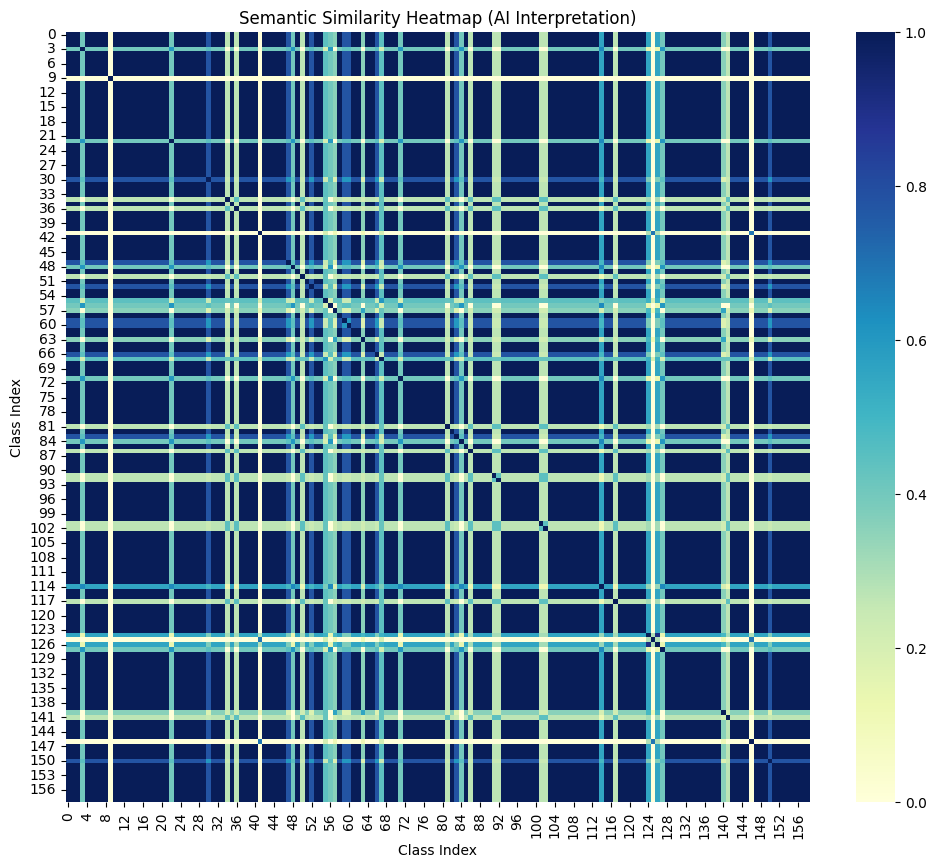

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
# Using a different color map (YlGnBu) helps distinguish the gradients
sns.heatmap(semantic_stretched, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Semantic Similarity Heatmap (AI Interpretation)")
plt.xlabel("Class Index")
plt.ylabel("Class Index")
plt.show()

In [26]:
semantic_matrix_test.shape

(64, 64)

In [27]:
print(embeddings[0])

[-1.122939    0.69376695 -0.77143514 ...  2.1282232   0.36934754
 -0.8939236 ]


In [28]:
semantic_stretched.shape

(159, 159)

In [29]:
semantic_matrix = semantic_stretched

**6. Construct the structural similarity matrix**

In [30]:
# scan the filtered .rsf dependency file from week 1 to construct a matrix where each entry is the number of packages each pair of files depend on.
# executing this cell produces 'struct_matrix_raw'
class_to_index = {name: i for i, name in enumerate(cleaned_class_list)}
struct_matrix_raw = np.zeros((len(cleaned_class_list), len(cleaned_class_list)))

with open(focused_rsf_path, mode="r") as f:
    for line in f:
        rsf_contents = line.strip().split(" ")
        # print(src,dest)
        src, dest = rsf_contents[1], rsf_contents[2]
        if src in class_to_index and dest in class_to_index:
           i = class_to_index[src]
           j = class_to_index[dest]

           # Mark the connection
          #  print(f"connection: {src} to {dest}")
           struct_matrix_raw[i][j] = 1


In [31]:
print(struct_matrix_raw)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


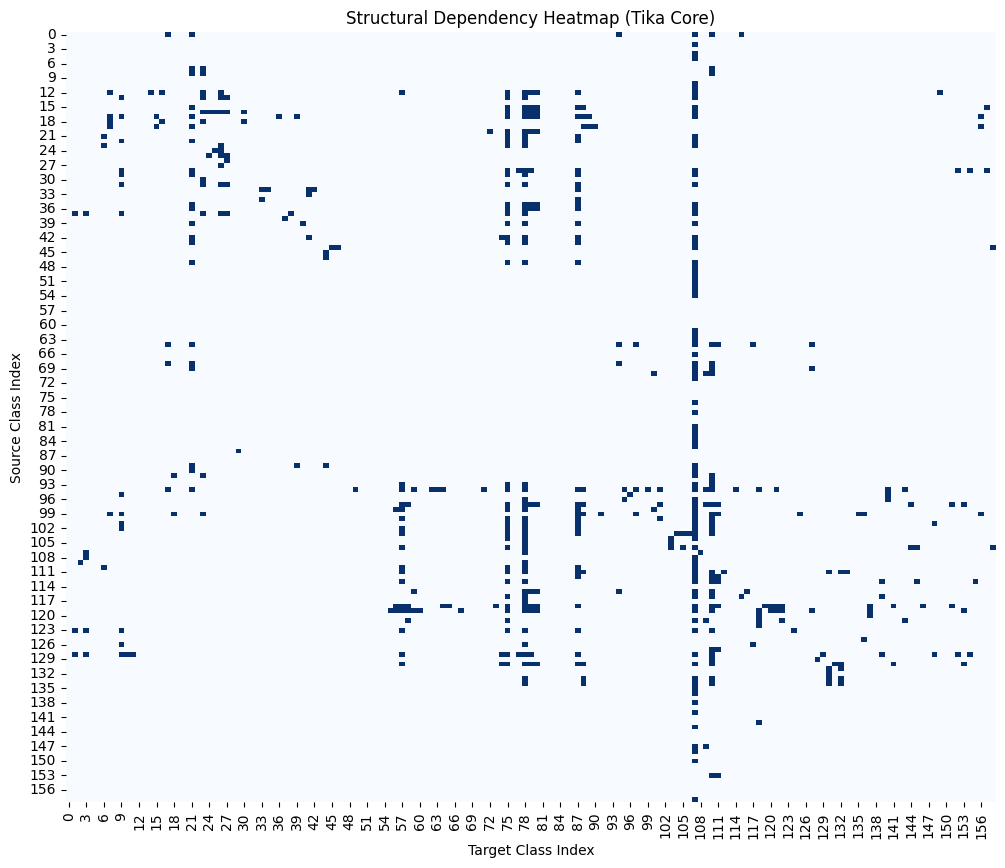

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(struct_matrix_raw, cmap="Blues", cbar=False)
plt.title("Structural Dependency Heatmap (Tika Core)")
plt.xlabel("Target Class Index")
plt.ylabel("Source Class Index")
plt.show()

**7. Normalize the structural matrix**

In [33]:
max_overlap = struct_matrix_raw.max()
struct_matrix = struct_matrix_raw / max_overlap if max_overlap > 0 else struct_matrix_raw
np.fill_diagonal(struct_matrix, 1.0)

**8. Combine the two matrices into one similarity matrix then apply complement.**

In [34]:
ALPHA = 0.5
combined_similarity = (ALPHA * struct_matrix) + ((1 - ALPHA) * semantic_matrix)

# Ensure similarity values are within [0, 1] before converting to distance
combined_similarity = np.clip(combined_similarity, 0.0, 1.0)

# Invert similarity to get distance
distance_matrix = 1.0 - combined_similarity
np.fill_diagonal(distance_matrix, 0)

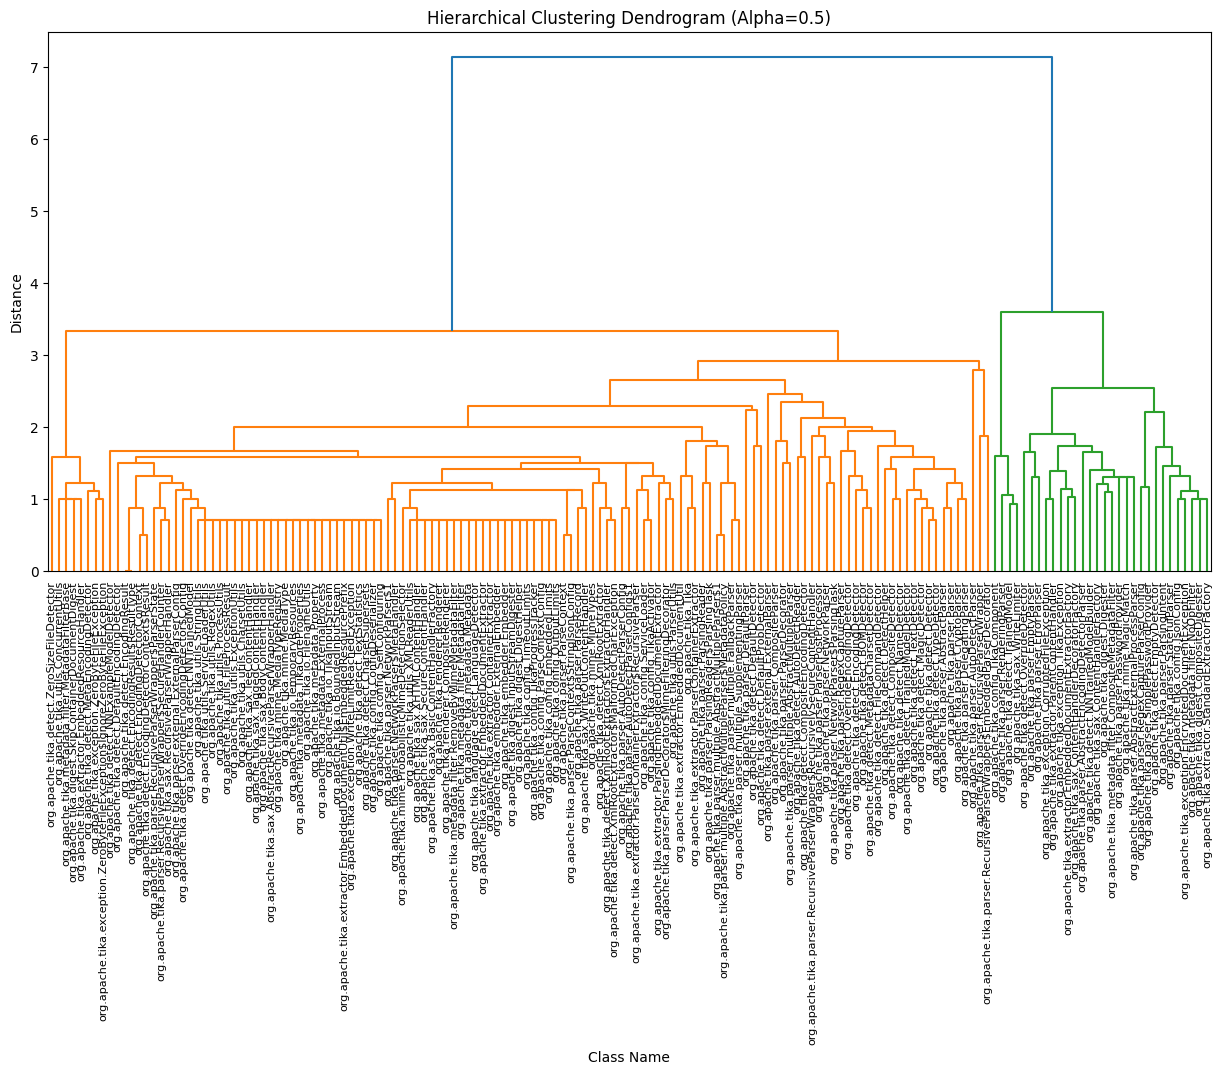

In [35]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(distance_matrix, method='complete')

plt.figure(figsize=(15, 7))
dendrogram(Z, labels=cleaned_class_list, leaf_rotation=90, leaf_font_size=8)
plt.title(f"Hierarchical Clustering Dendrogram (Alpha={ALPHA})")
plt.xlabel("Class Name")
plt.ylabel("Distance")
plt.show()

**9. Apply clustering**

In [36]:
TARGET_NUM_CLUSTERS = 15 # how such parameter could be optimized?
clusterer = AgglomerativeClustering(n_clusters=TARGET_NUM_CLUSTERS, metric='precomputed', linkage='complete') # what is 'precomputed' & 'linkage'?
clusters = clusterer.fit_predict(distance_matrix)

In [37]:
import pandas as pd

# Create a summary table
cluster_summary = pd.Series(clusters).value_counts().sort_index().reset_index()
cluster_summary.columns = ['Cluster ID', 'File Count']
cluster_summary['Percentage'] = (cluster_summary['File Count'] / len(clusters)) * 100

print(cluster_summary.to_string(index=False))

 Cluster ID  File Count  Percentage
          0           5    3.144654
          1           5    3.144654
          2           3    1.886792
          3           2    1.257862
          4         123   77.358491
          5           2    1.257862
          6           2    1.257862
          7           1    0.628931
          8           3    1.886792
          9           7    4.402516
         10           2    1.257862
         11           1    0.628931
         12           1    0.628931
         13           1    0.628931
         14           1    0.628931


In [38]:
clusters

array([ 4,  4,  4,  9,  4,  4,  4,  4,  4,  7,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  9,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        0,  4,  6,  4,  4,  4,  4,  2,  4,  4,  4,  4,  4,  4,  9,  4,  0,
        4,  4,  4,  4,  1,  9,  3,  4,  4,  4,  4,  4,  3,  4,  4,  4,  1,
        4, 10,  4,  9,  4,  4,  4,  4,  4,  4,  4,  4,  6,  0,  4,  4,  9,
        4,  0,  4,  4,  4,  4,  0, 14,  4,  4,  8,  8,  4,  4,  4,  4,  5,
       13,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  9,  4,  4, 12,  4,
        4,  4,  4,  4,  1,  1,  2,  1, 10,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  8, 11,  4,  4,  4,  4,  2,  4,  5,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4])

**10. Visulizations**

In [40]:
# According to the applied algorithm documentation, provide any visualizations for better understanding of how the clusters are formed.

In [39]:
import csv

output_rsf_path = "/content/arc_clusters.rsf"

with open(output_rsf_path, mode="w", encoding="utf-8") as f:
    for idx, cluster_id in enumerate(clusters):
        class_name = cleaned_class_list[idx]

        f.write(f"contain Cluster_{cluster_id} {class_name}\n")

print(f"RSF file successfully generated at: {output_rsf_path}")

RSF file successfully generated at: /content/arc_clusters.rsf
